# COF-Landscaper local workflow

In [6]:
import coflandscaper as cl

In [15]:
TOPOLOGY = "hcb"
COF_NAME = "PBI-COF"
MODE = "both"

In [ ]:
constructor = cl.ConstructCOFfromCIF()

constructor.run(
    cof_name=COF_NAME,
    input_cif="0_input/PBI-COF.cif",
)

In [16]:
matrix = cl.CreateMatrix(
    ild_start=3.0,
    ild_end=4.0,
)

matrix.run(
    cof_name=COF_NAME,
    topo=TOPOLOGY,
    mode=MODE,
)

In [ ]:
sp = cl.MaceSP()
sp.run(cof_name=COF_NAME, mode=MODE)

### Potential Energy Landscape (PES)

This step plots an approximate stacking potential energy surface by mapping the relative energies of the generated ILD/ILS structure matrix as a function of interlayer distance (ILD) and interlayer slipping (ILS).

Because no full structural relaxation is performed at this stage, the PES is treated as a reduced-dimensional screening model rather than a full description of the underlying high-dimensional energy landscape. Within this approximation, it provides a qualitative to semi-quantitative representation of the relative stability of different stacking arrangements and serves to identify candidate minima for subsequent refinement by full geometry optimization.

---

- `show` *(bool, optional, default: `False`)*  
  If `True`, displays interactive plot windows.  

- PES plots `pes_{COF_NAME}_{serr|incl}.png` default written to:  
  `COF_NAME/3_{COF_NAME}_landscape/`

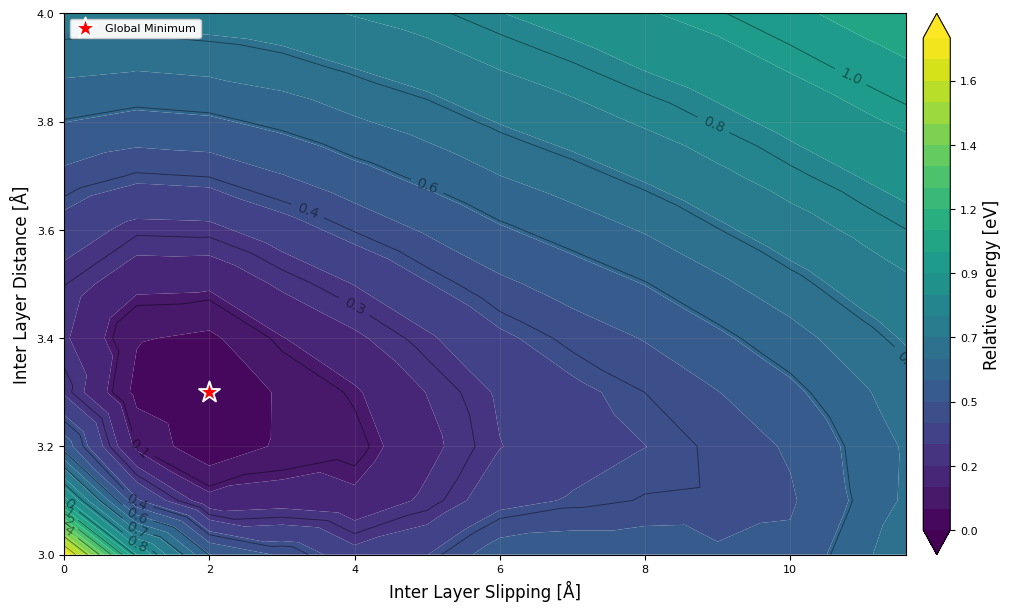

Saved: PBI-COF/3_PBI-COF_landscape/pes_PBI-COF_incl.png


In [9]:
landscape = cl.Landscape()

landscape.run(
    cof_name=COF_NAME,
    mode=MODE,
    show=True,
    show_minima_markers=True,
)

In [ ]:
EXTRA_SERR = []
EXTRA_INCL = [(3.2, 16.4)]

In [ ]:
selector = cl.SelectCofs()

selector.run(
    cof_name=COF_NAME,
    mode=MODE,
    selections_serr=EXTRA_SERR,
    selections_incl=EXTRA_INCL,
    include_autoselect=False,
)

In [ ]:
landscape = cl.Landscape()

landscape.run(
    cof_name=COF_NAME,
    mode=MODE,
    input_folder=f"{COF_NAME}/refined_sp",
    output_folder=f"{COF_NAME}/refined_landscape",
    show=True,
)

### Structure Selection for Optimization

This step selects candidate structures corresponding to automatically detected global or local minima and copies them into dedicated folders for subsequent geometry optimization.

By default, the global minimum of each stacking mode is selected automatically. Local minima can instead be selected by setting the corresponding minima option.

Additional sampling points identified from inspection of the simplified PES can also be included by providing `(ILD, ILS)` pairs separately for the serrated and inclined stacking modes, for example:

```python
EXTRA_SERR = [(3.4, 2.0), (3.5, 1.0)]
EXTRA_INCL = [(3.3, 2.0)]

In [ ]:
import inspect

print(inspect.signature(cl.SelectCofs.run))
print(inspect.signature(cl.MaceOpt.run))

In [ ]:
EXTRA_SERR = []
EXTRA_INCL = [(4.4, 17.0)]

In [ ]:
selector = cl.SelectCofs()

selector.run(
    cof_name=COF_NAME,
    mode=MODE,
    selections_serr=EXTRA_SERR,
    selections_incl=EXTRA_INCL,
    include_autoselect=False,
    input_folder=f"{COF_NAME}/refined_matrix/{MODE}",
    output_folder=f"{COF_NAME}/refined_selected/{MODE}",
)

### MACE Geometry Optimization

This step performs geometry optimizations of selected stacking structures using `MaceOpt`.

`MaceOpt` uses ASE `FrechetCellFilter` + `LBFGS`, writes optimized CIF files, and can write a combined energy CSV (`{COF_NAME}_opt_energies_per_layer.csv`).

  Optimized structures (`.cif`) and optional energies CSV are written to:  
  `COF_NAME/4_{COF_NAME}_optimization/`

In [ ]:
opt = cl.MaceOpt()

opt.run(
    cof_name=COF_NAME,
    mode=MODE,
    input_base=f"{COF_NAME}/refined_selected",
    output_base=f"{COF_NAME}/refined_optimization",
)

In [ ]:
opt = cl.MaceOpt()
opt.run(cof_name=COF_NAME, mode=MODE)

In [ ]:
import inspect

print(inspect.signature(cl.AnalyzeStacking.analyze))
print(inspect.signature(cl.PXRD.run))
print(inspect.signature(cl.PXRD.plot_sim_vs_exp))

In [ ]:
analyzer = cl.AnalyzeStacking()

analyzer.analyze(
    cof_name=COF_NAME,
    mode=MODE,
    input_base=f"{COF_NAME}/refined_optimization",
    output_base=f"{COF_NAME}/refined_analysis",
)

In [ ]:
pxrd = cl.PXRD(
    wavelength="CuKa",
    two_theta_range=(1.5, 30.0),
)

pxrd.run(
    cof_name=COF_NAME,
    mode=MODE,
    input_folder=f"{COF_NAME}/refined_optimization/{MODE}",
    output_folder=f"{COF_NAME}/refined_pxrd_xy/{MODE}",
)

In [ ]:
pxrd.plot_sim_vs_exp(
    cof_name=COF_NAME,
    mode=MODE,
    simulated_xy_folder=f"{COF_NAME}/refined_pxrd_xy/{MODE}",
    output_folder=f"{COF_NAME}/refined_pxrd_plots",
    xlim=(3, 30),
)

### Analysis & Visualization

This step analyzes optimized structures by computing interlayer distance (ILD) and interlayer slipping (ILS) from the optimized structures, and writing a summary CSV for comparison across stacking configurations.

In addition, structures can be visualized using an interactive viewer.

In [ ]:
analyzer = cl.AnalyzeStacking()
analyzer.analyze(cof_name=COF_NAME, mode=MODE)

In [ ]:
visualizer = cl.VisualizeCOF()
visualizer.visualize_cof(cof_name=COF_NAME, mode=MODE)

### PXRD simulation

Simulate PXRD patterns from the optimized structures. The simulated `.xy` patterns are written to the analysis-stage `pxrd_xy` folders.

In [21]:
supercell = cl.Supercell()

supercell.run(
    input_folder="PBI-COF/4_PBI-COF_optimization/incl",
    output_folder="PBI-COF/4_PBI-COF_optimization/supercell",
    supercell_size=(1, 1, 2),

)

In [25]:
pxrd = cl.PXRD(wavelength="CuKa", two_theta_range=(1.5, 30.0))
pxrd.run(cof_name=COF_NAME, mode=MODE)

{'serr': 'PBI-COF/5_PBI-COF_analysis/pxrd_xy/serr',
 'incl': 'PBI-COF/5_PBI-COF_analysis/pxrd_xy/incl'}

#### Simulated peak tables

Extract simulated reflections (100 by default) per structure . The resulting peak lists are saved as `<structure>_all.csv` in the mode-specific `pxrd_peaks` folders.

In [ ]:
pxrd.extract_peaks(cof_name=COF_NAME, mode=MODE)

### Experimental comparison

Place exactly one experimental `.xy` file in `experimental_pxrd/`, or pass its path explicitly. The comparison generates one PDF per simulated structure in `pxrd_plots`.

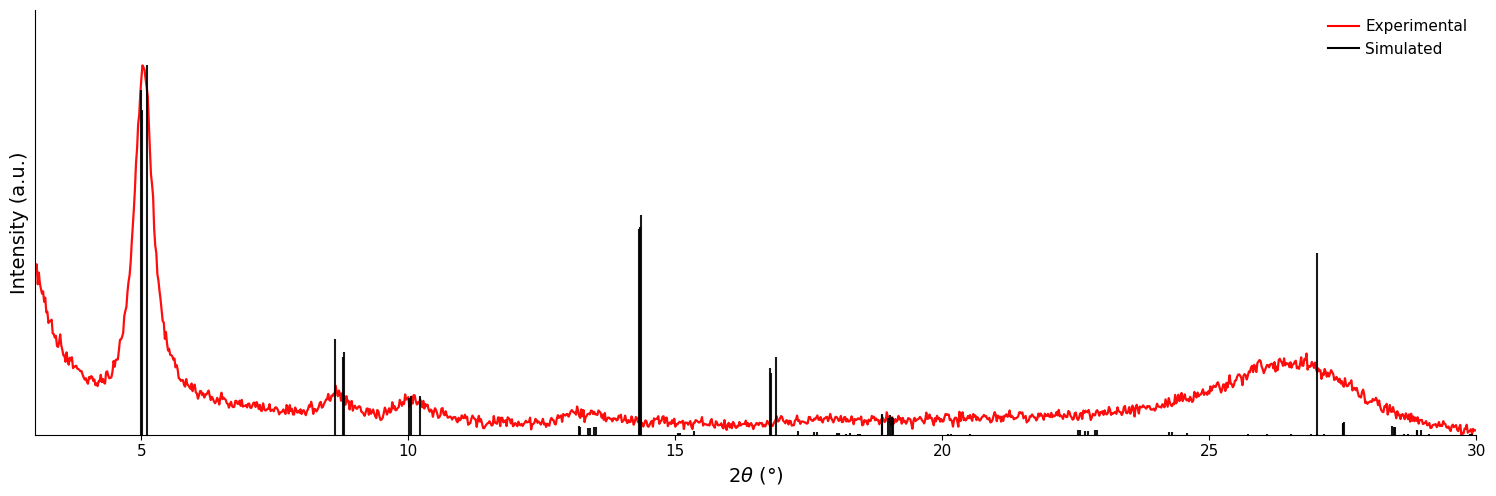

Plotted simulated and experimental PXRD pattern for PBI-COF_z33_L116_serr_unopt.cif


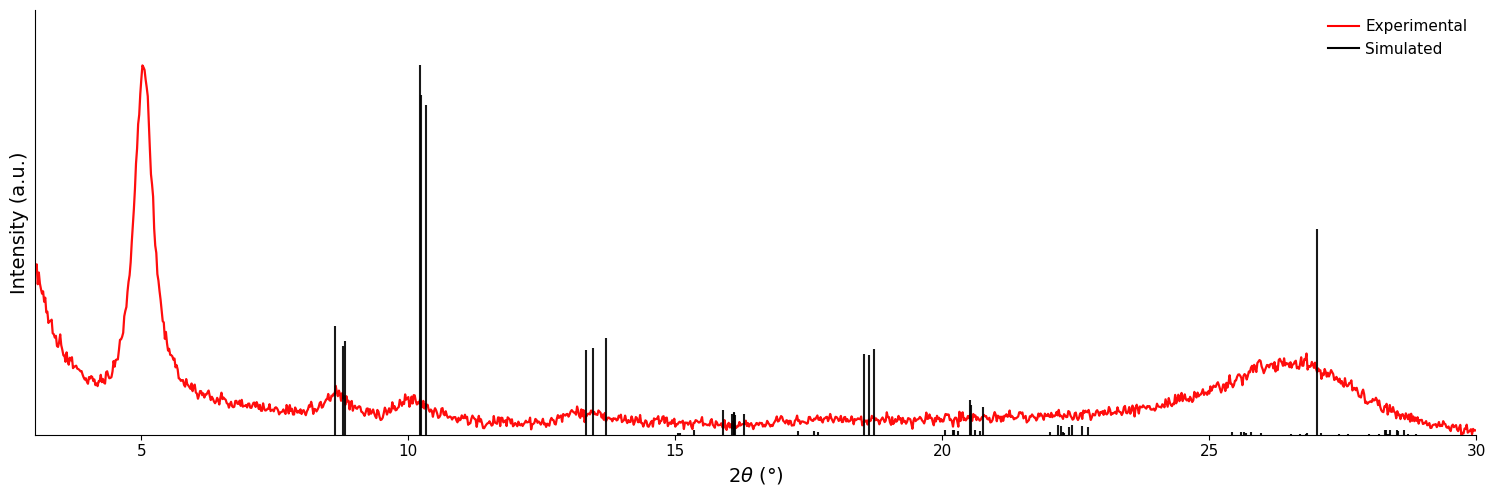

Plotted simulated and experimental PXRD pattern for PBI-COF_z33_L116_incl_unopt.cif


['PBI-COF/5_PBI-COF_analysis/pxrd_plots/serr/PBI-COF_z33_L116_serr_unopt.pdf',
 'PBI-COF/5_PBI-COF_analysis/pxrd_plots/incl/PBI-COF_z33_L116_incl_unopt.pdf']

In [27]:
pxrd.plot_sim_vs_exp(
    cof_name=COF_NAME,
    mode="both",
    xlim=(3, 30),
)

## PXRD-guided refinement

The simulated and experimental PXRD patterns should first be inspected qualitatively. The refinement described below is intended for structures that already reproduce the experimental pattern reasonably well but show a **systematic offset in peak positions**. It is not intended to correct a stacking model whose simulated PXRD pattern is fundamentally inconsistent with experiment.

A consistent displacement of corresponding simulated and experimental reflections can indicate that the predicted structure is qualitatively correct while its unit-cell dimensions differ slightly from those of the experimental material. COF-Landscaper therefore provides a simple PXRD-guided refinement in which experimental diffraction peak positions are used to adjust the in-plane dimensions of the calculated structure. This follows the general principle of refining lattice dimensions against diffraction data.

If both serrated and inclined structures were evaluated above, first select the stacking mode(s) that provides the physically meaningful agreement with experiment. The comparison is performed within **user-defined 2θ regions**. Each region should contain an experimental feature and the corresponding simulated reflection that the user intends to compare.

A region is specified by its lower and upper 2θ limits:
Example:
```python

peak_regions = [
    (4.0, 5.5),
    (7.5, 9.0),
    (9.0, 10.5),
]

In [ ]:
MODE = "serr"

In [ ]:
peak_regions = [
    (4.0, 5.5),
    (7.5, 9),
    (9, 10.5),
    (12, 14),
    (15.5, 17.5),
    (24, 27.5),
]

pxrd.extract_peak_regions(
    cof_name=COF_NAME,
    mode=MODE,
    peak_regions=peak_regions,
)

### In-plane lattice scaling

The extracted experimental and simulated peak positions are used to estimate the in-plane lattice correction required to improve their agreement.

By default, all extracted peak regions are included (`scale_regions=None`). If some experimental features are broad, overlapping, or otherwise unsuitable for a reliable comparison, `scale_regions` can be used to restrict the scaling to selected regions.

For example, to use only regions 1, 2, and 4:

```python
scale_regions = [1, 2, 4]

In [ ]:
scaled_cifs = pxrd.generate_scaled_cif(
    cof_name=COF_NAME,
    mode=MODE,
    scale_regions=[1,2],
)

### Post-optimization

The PXRD-guided scaling changes the unit-cell dimensions geometrically. The scaled structure is therefore subsequently re-optimized with MACE while keeping the refined unit cell fixed, allowing the atomic coordinates to relax within the experimentally informed cell.

In [ ]:
postopt = cl.MaceOpt()
postopt.run_fixed(cof_name=COF_NAME, mode=MODE)

## Postopt analysis

Repeat structural and PXRD analysis against the post-optimized structures using `source="postopt"`.

In [ ]:
analyzer = cl.AnalyzeStacking()
analyzer.analyze(cof_name=COF_NAME, mode=MODE, source="postopt")

In [ ]:
pxrd.run(cof_name=COF_NAME, mode=MODE, source="postopt")
pxrd.extract_peaks(cof_name=COF_NAME, mode=MODE, source="postopt")
pxrd.extract_peak_regions(
    cof_name=COF_NAME,
    mode=MODE,
    peak_regions=peak_regions,
    source="postopt",
)

In [ ]:
pxrd.plot_sim_vs_exp(
    cof_name=COF_NAME,
    mode=MODE,
    source="postopt",
    xlim=(3.5, 30.0),
)

In [ ]:
visualizer = cl.VisualizeCOF()
visualizer.visualize_cof(
    cof_name=COF_NAME,
    mode=MODE,
    source="postopt",
)